In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
from sklearn.metrics import confusion_matrix, classification_report

# Extract the dataset
with zipfile.ZipFile("/content/banglaSER_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/banglaSER_extracted")

# Define dataset path
AUDIO_DIR = "/content/banglaSER_extracted"

# Define emotion mapping
EMOTION_MAPPING = {
    '01': 'happy',
    '02': 'sad',
    '03': 'angry',
    '04': 'surprise',
    '05': 'neutral'
}

# Create dataset info function
def create_dataset_info(root_path, extract_duration=True):

    data = []

    for root, _, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = EMOTION_MAPPING.get(emotion_code, 'unknown')
                    file_path = os.path.join(root, file)

                    entry = {
                        'file_path': file_path,
                        'emotion_code': emotion_code,
                        'emotion': emotion
                    }

                    if extract_duration:
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            duration = librosa.get_duration(y=y, sr=sr)
                            entry['duration_sec'] = duration
                            entry['sample_rate'] = sr
                        except Exception as e:
                            print(f"Could not read {file_path}: {e}")
                            continue

                    data.append(entry)

    return pd.DataFrame(data)

# Create dataset info
df = create_dataset_info(AUDIO_DIR)
print(f"\nTotal samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
df.head()



Total samples: 1467

Emotion distribution:
emotion
sad         306
angry       306
surprise    306
happy       306
neutral     243
Name: count, dtype: int64


,file_path,emotion_code,emotion,duration_sec,sample_rate
0,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.037313,48000
1,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.118688,48000
2,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,05,neutral,3.126531,44100
3,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,02,sad,3.037313,48000
4,/content/banglaSER_extracted/t9h6p943xy-5/Bang...,03,angry,3.027750,48000


Train: 1173, Validation: 147, Test: 147


/tmp/ipython-input-2-103373298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-2-103373298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
/tmp/ipython-input-2-103373298.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')


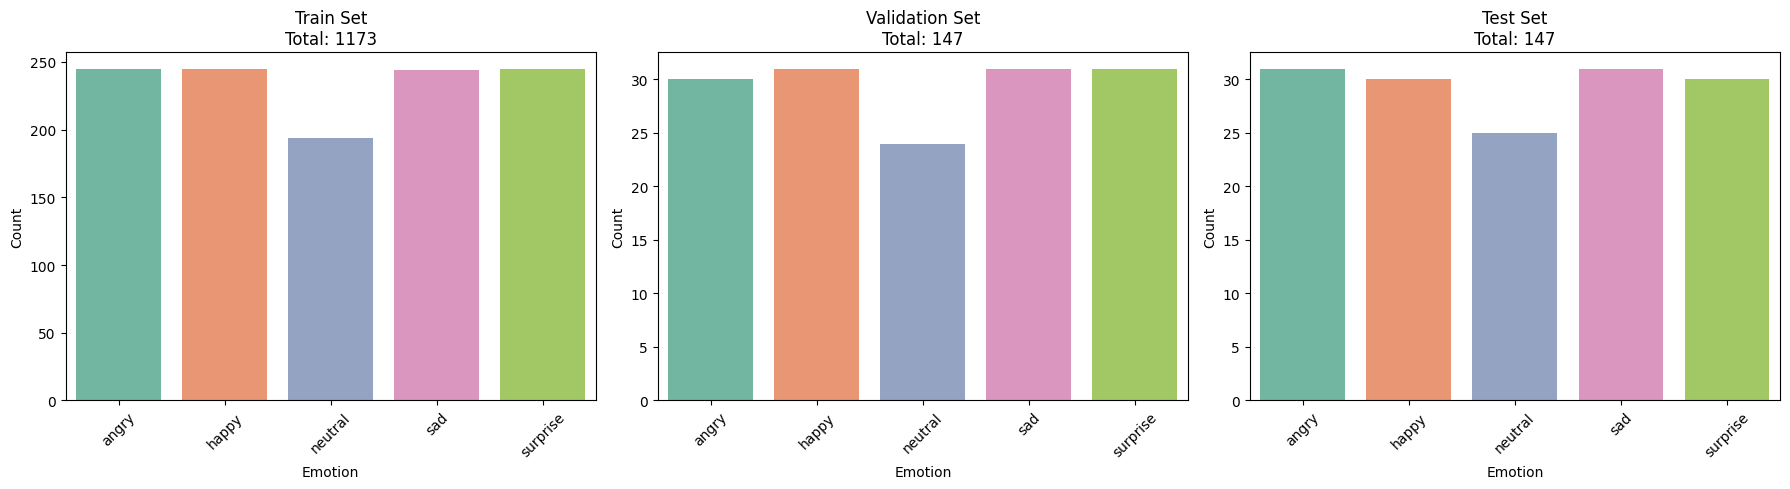

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 32)


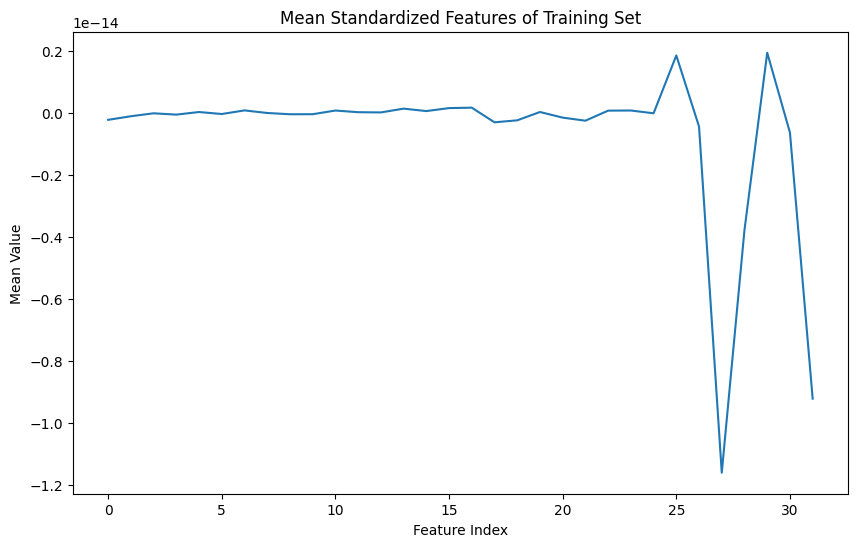

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4


In [ ]:
# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function
def extract_features(file_path):
    y, sr = librosa.load(file_path, sr=None)

    # Extract MFCCs
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
    mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

    # Extract Chroma feature
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

    # Extract Spectral Contrast
    spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    spectral_contrast = np.mean(spectral_contrast, axis=1)

    # Combine all features into one vector
    features = np.hstack([mfcc, chroma, spectral_contrast])
    return features

# Extract features for each split
print("Extracting features for training set...")
train_features = [extract_features(file) for file in train_df['file_path']]
print("Extracting features for validation set...")
val_features = [extract_features(file) for file in val_df['file_path']]
print("Extracting features for test set...")
test_features = [extract_features(file) for file in test_df['file_path']]

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train.shape)

# Visualize feature means
plt.figure(figsize=(10, 6))
plt.plot(np.mean(X_train, axis=0))
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.show()

# Encode labels
label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df['emotion'])
val_labels = label_encoder.transform(val_df['emotion'])
test_labels = label_encoder.transform(test_df['emotion'])

# Convert to one-hot encoding
y_train = to_categorical(train_labels)
y_val = to_categorical(val_labels)
y_test = to_categorical(test_labels)

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

### SVM model

Enhanced Feature Extraction: Added additional audio features for better SVM performance:

Zero Crossing Rate (ZCR)
Spectral Centroid
Spectral Rolloff


SVM Implementation with Grid Search:

Automated hyperparameter tuning using GridSearchCV
Tests multiple kernels (RBF, Linear, Polynomial)
Optimizes C and gamma parameters
5-fold cross-validation for robust evaluation


Comprehensive Evaluation:

Accuracy scores for validation and test sets
Detailed classification report
Confusion matrix visualization
Feature importance analysis (for linear kernels)


Total samples: 1467

Emotion distribution:
emotion
sad         306
angry       306
surprise    306
happy       306
neutral     243
Name: count, dtype: int64
                                           file_path emotion_code  emotion  \
0  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           02      sad   
1  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           02      sad   
2  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           05  neutral   
3  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           02      sad   
4  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           03    angry   

   duration_sec  sample_rate  
0      3.037313        48000  
1      3.118688        48000  
2      3.126531        44100  
3      3.037313        48000  
4      3.027750        48000  
Train: 1173, Validation: 147, Test: 147


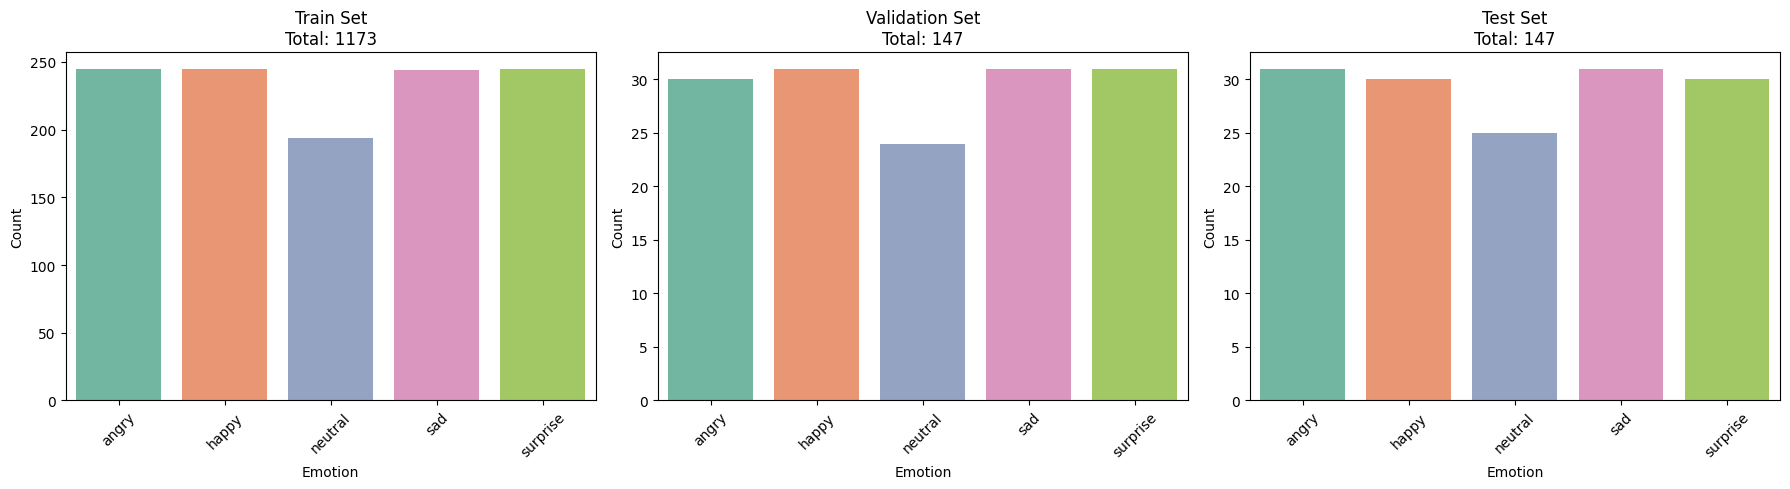

Extracting features for training set...
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (1173, 35)
Feature vector length: 35


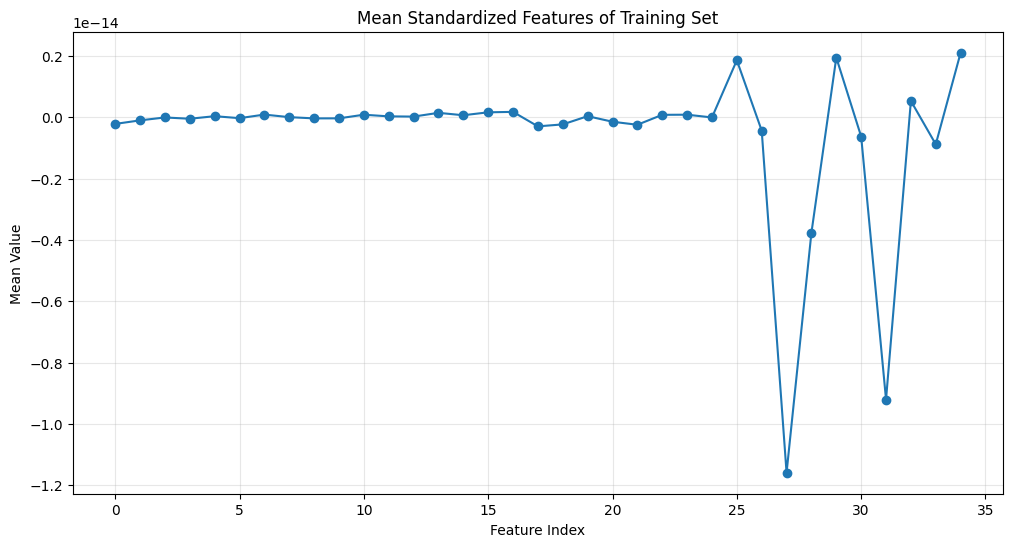

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4

SVM MODEL TRAINING
Performing Grid Search for optimal SVM parameters...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters found:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.8576

Making predictions...

Validation Accuracy: 0.9048
Test Accuracy: 0.8707

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

       angry       0.97      0.97      0.97        31
       happy       0.77      0.77      0.77        30
     neutral       0.96      0.92      0.94        25
         sad       0.82      0.90      0.86        31
    surprise       0.86      0.80      0.83        30

    accuracy                           0.87       147
   macro avg       0.87      0.87      0.87       147
weighted avg       0.87      0.87      0.87       147



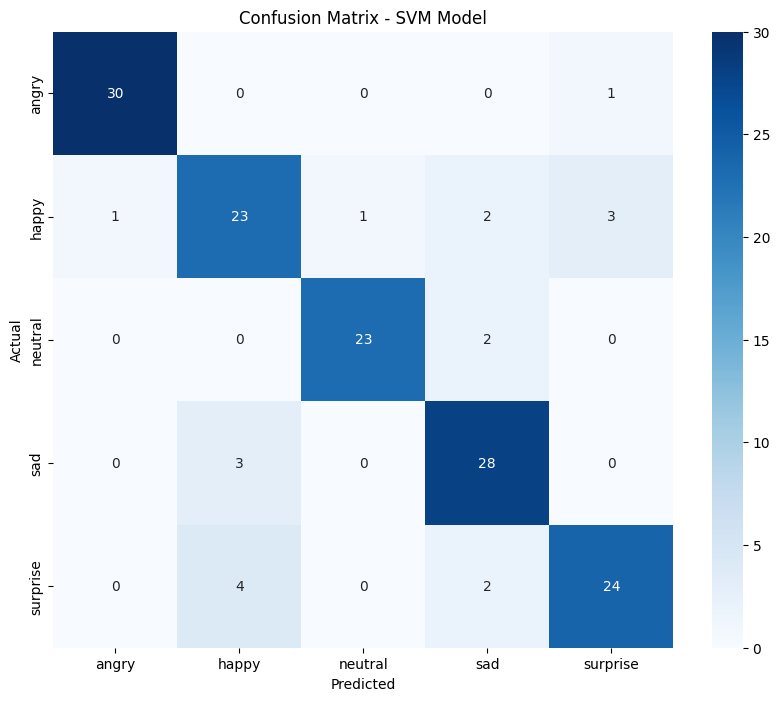


MODEL SUMMARY
Best SVM Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Cross-validation Score: 0.8576
Validation Accuracy: 0.9048
Test Accuracy: 0.8707

SVM model training completed!


In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

# Extract the dataset
with zipfile.ZipFile("/content/banglaSER_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/banglaSER_extracted")

# Define dataset path
AUDIO_DIR = "/content/banglaSER_extracted"

# Define emotion mapping
EMOTION_MAPPING = {
    '01': 'happy',
    '02': 'sad',
    '03': 'angry',
    '04': 'surprise',
    '05': 'neutral'
}

# Create dataset info function
def create_dataset_info(root_path, extract_duration=True):
    data = []
    for root, _, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = EMOTION_MAPPING.get(emotion_code, 'unknown')
                    file_path = os.path.join(root, file)

                    entry = {
                        'file_path': file_path,
                        'emotion_code': emotion_code,
                        'emotion': emotion
                    }

                    if extract_duration:
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            duration = librosa.get_duration(y=y, sr=sr)
                            entry['duration_sec'] = duration
                            entry['sample_rate'] = sr
                        except Exception as e:
                            print(f"Could not read {file_path}: {e}")
                            continue

                    data.append(entry)

    return pd.DataFrame(data)

# Create dataset info
df = create_dataset_info(AUDIO_DIR)
print(f"\nTotal samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
print(df.head())

# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Feature extraction function (Fixed syntax error)
def extract_features(file_path):
    try:
        y, sr = librosa.load(file_path, sr=None)

        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

        # Extract Chroma feature
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients (Fixed syntax error)

        # Extract Spectral Contrast
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        spectral_contrast = np.mean(spectral_contrast, axis=1)

        # Extract additional features for better SVM performance
        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr = np.mean(zcr)

        # Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid = np.mean(spectral_centroid)

        # Spectral Rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff = np.mean(spectral_rolloff)

        # Combine all features into one vector
        features = np.hstack([mfcc, chroma, spectral_contrast, zcr, spectral_centroid, spectral_rolloff])
        return features
    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None

# Extract features for each split
print("Extracting features for training set...")
train_features = []
for file_path in train_df['file_path']:
    features = extract_features(file_path)
    if features is not None:
        train_features.append(features)

print("Extracting features for validation set...")
val_features = []
for file_path in val_df['file_path']:
    features = extract_features(file_path)
    if features is not None:
        val_features.append(features)

print("Extracting features for test set...")
test_features = []
for file_path in test_df['file_path']:
    features = extract_features(file_path)
    if features is not None:
        test_features.append(features)

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train_scaled.shape)
print("Feature vector length:", X_train_scaled.shape[1])

# Visualize feature means
plt.figure(figsize=(12, 6))
plt.plot(np.mean(X_train_scaled, axis=0), marker='o')
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.grid(True, alpha=0.3)
plt.show()

# Encode labels for SVM (no need for one-hot encoding)
label_encoder = LabelEncoder()
y_train_svm = label_encoder.fit_transform(train_df['emotion'])
y_val_svm = label_encoder.transform(val_df['emotion'])
y_test_svm = label_encoder.transform(test_df['emotion'])

# Print class mapping
print("Label mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# SVM Model Implementation
print("\n" + "="*60)
print("SVM MODEL TRAINING")
print("="*60)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

print("Performing Grid Search for optimal SVM parameters...")
# Initialize SVM with GridSearchCV
svm_model = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train the SVM model
svm_model.fit(X_train_scaled, y_train_svm)

print("Best parameters found:")
print(svm_model.best_params_)
print(f"Best cross-validation score: {svm_model.best_score_:.4f}")

# Make predictions
print("\nMaking predictions...")
y_val_pred = svm_model.predict(X_val_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Calculate accuracies
val_accuracy = accuracy_score(y_val_svm, y_val_pred)
test_accuracy = accuracy_score(y_test_svm, y_test_pred)

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test_svm, y_test_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_svm, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance analysis (for linear kernel)
if svm_model.best_params_['kernel'] == 'linear':
    # Get feature importance for linear SVM
    feature_importance = np.abs(svm_model.best_estimator_.coef_[0])

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(feature_importance)), feature_importance)
    plt.title('Feature Importance (Linear SVM)')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()

    # Print top 10 most important features
    top_features = np.argsort(feature_importance)[-10:][::-1]
    print("\nTop 10 Most Important Features:")
    for i, idx in enumerate(top_features):
        print(f"{i+1}. Feature {idx}: {feature_importance[idx]:.4f}")

# Model comparison summary
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Best SVM Parameters: {svm_model.best_params_}")
print(f"Cross-validation Score: {svm_model.best_score_:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save the model (optional)
# import joblib
# joblib.dump(svm_model, 'banglaser_svm_model.pkl')
# joblib.dump(scaler, 'banglaser_scaler.pkl')
# joblib.dump(label_encoder, 'banglaser_label_encoder.pkl')
# print("\nModel saved successfully!")

print("\nSVM model training completed!")

### with augmentation

Data Augmentation:

Noise Addition: Adds random noise to audio signals
Time Shifting: Shifts audio in time domain
Pitch Shifting: Changes pitch without affecting tempo
Time Stretching: Changes tempo without affecting pitch
3x Data Multiplication: Each training sample generates 2 additional augmented versions
Balanced Augmentation: Applied only to training set (not validation/test)


Total samples: 1467

Emotion distribution:
emotion
sad         306
angry       306
surprise    306
happy       306
neutral     243
Name: count, dtype: int64
                                           file_path emotion_code  emotion  \
0  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           02      sad   
1  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           02      sad   
2  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           05  neutral   
3  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           02      sad   
4  /content/banglaSER_extracted/t9h6p943xy-5/Bang...           03    angry   

   duration_sec  sample_rate  
0      3.037313        48000  
1      3.118688        48000  
2      3.126531        44100  
3      3.037313        48000  
4      3.027750        48000  
Train: 1173, Validation: 147, Test: 147


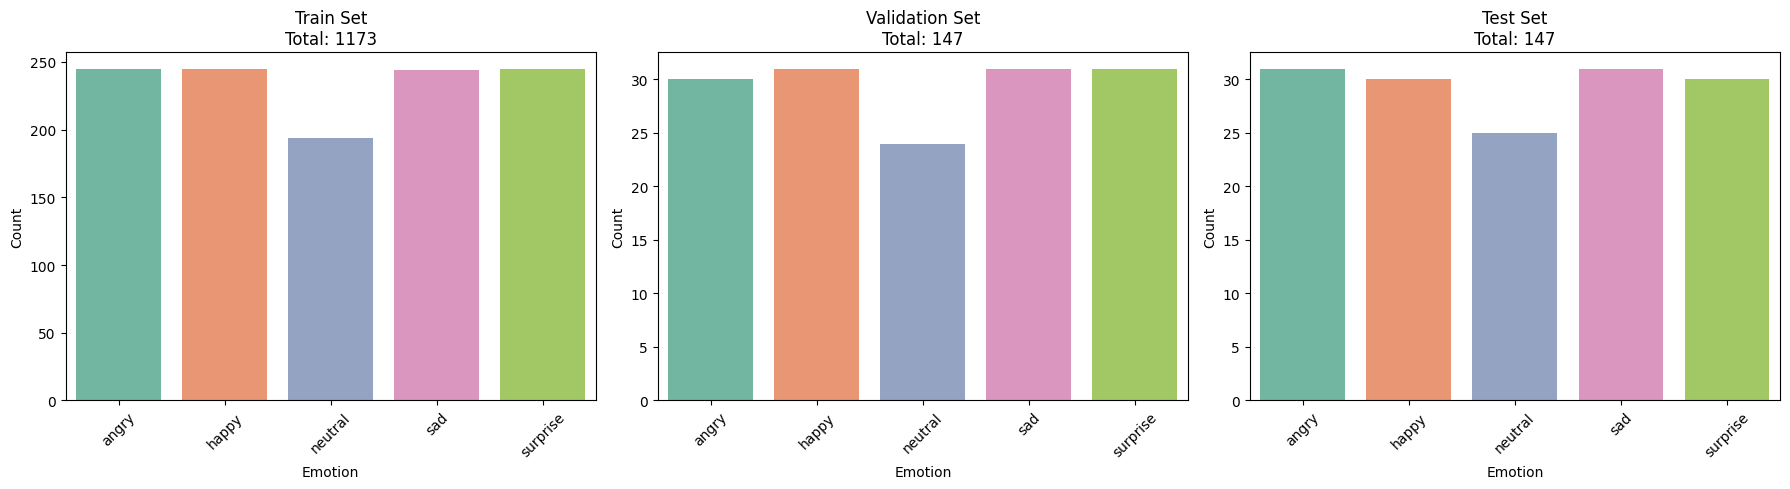

Extracting features for training set (with augmentation)...
Training samples after augmentation: 3519 (original: 1173)
Extracting features for validation set...
Extracting features for test set...
X_train shape after scaling: (3519, 35)
Feature vector length: 35


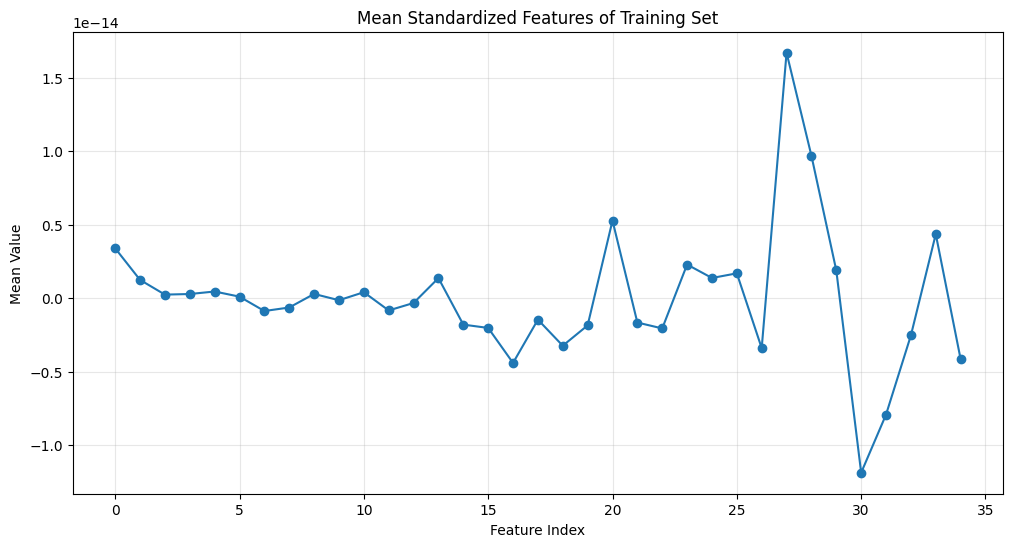


Augmented training set size: 3519
Emotion distribution after augmentation:
angry: 735
happy: 735
neutral: 582
sad: 732
surprise: 735

Label mapping:
angry: 0
happy: 1
neutral: 2
sad: 3
surprise: 4

SVM MODEL TRAINING
Performing Grid Search for optimal SVM parameters...
Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best parameters found:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best cross-validation score: 0.7926

Making predictions...

Validation Accuracy: 0.9048
Test Accuracy: 0.8844

CLASSIFICATION REPORT (Test Set)
              precision    recall  f1-score   support

       angry       0.97      0.97      0.97        31
       happy       0.79      0.77      0.78        30
     neutral       0.96      0.96      0.96        25
         sad       0.88      0.90      0.89        31
    surprise       0.83      0.83      0.83        30

    accuracy                           0.88       147
   macro avg       0.89      0.89      0.89       147
weighted avg       0.88  

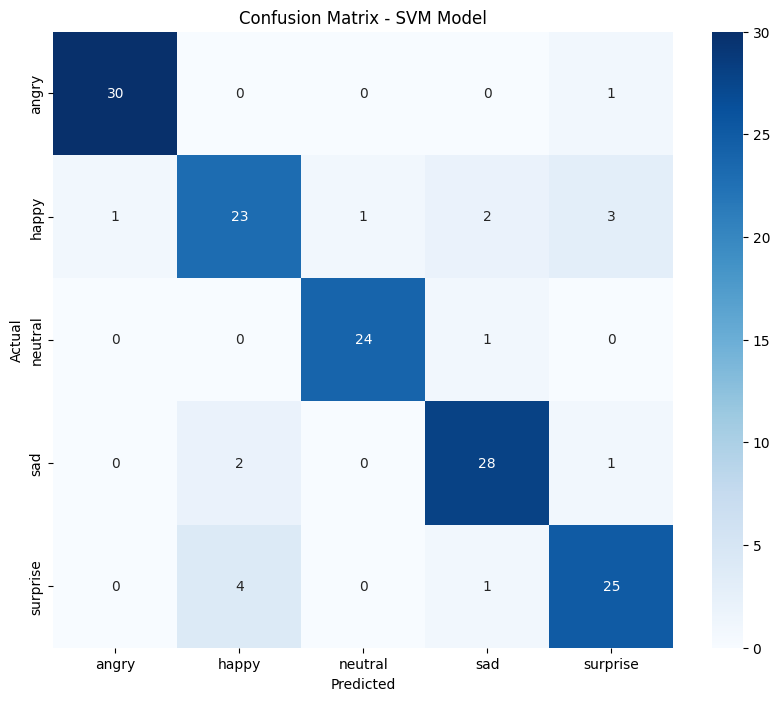


MODEL SUMMARY
Best SVM Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Cross-validation Score: 0.7926
Validation Accuracy: 0.9048
Test Accuracy: 0.8844

SVM model training completed!


In [ ]:
import os
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import layers, models
import warnings
warnings.filterwarnings('ignore')

# Extract the dataset
with zipfile.ZipFile("/content/banglaSER_dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/banglaSER_extracted")

# Define dataset path
AUDIO_DIR = "/content/banglaSER_extracted"

# Define emotion mapping
EMOTION_MAPPING = {
    '01': 'happy',
    '02': 'sad',
    '03': 'angry',
    '04': 'surprise',
    '05': 'neutral'
}

# Create dataset info function
def create_dataset_info(root_path, extract_duration=True):
    data = []
    for root, _, files in os.walk(root_path):
        for file in files:
            if file.lower().endswith('.wav'):
                parts = file.split('-')
                if len(parts) >= 3:
                    emotion_code = parts[2]
                    emotion = EMOTION_MAPPING.get(emotion_code, 'unknown')
                    file_path = os.path.join(root, file)

                    entry = {
                        'file_path': file_path,
                        'emotion_code': emotion_code,
                        'emotion': emotion
                    }

                    if extract_duration:
                        try:
                            y, sr = librosa.load(file_path, sr=None)
                            duration = librosa.get_duration(y=y, sr=sr)
                            entry['duration_sec'] = duration
                            entry['sample_rate'] = sr
                        except Exception as e:
                            print(f"Could not read {file_path}: {e}")
                            continue

                    data.append(entry)

    return pd.DataFrame(data)

# Create dataset info
df = create_dataset_info(AUDIO_DIR)
print(f"\nTotal samples: {len(df)}")
print("\nEmotion distribution:")
print(df['emotion'].value_counts())
print(df.head())

# Split the data into train, validation, and test sets
train_df, temp_df = train_test_split(
    df, test_size=0.2, stratify=df['emotion'], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, stratify=temp_df['emotion'], random_state=42
)

# Confirm split sizes
print(f"Train: {len(train_df)}, Validation: {len(val_df)}, Test: {len(test_df)}")

# Visualize the emotion distribution across splits
def plot_distribution(dataframes, labels):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for ax, df_split, label in zip(axes, dataframes, labels):
        sns.countplot(data=df_split, x='emotion', order=sorted(df['emotion'].unique()), ax=ax, palette='Set2')
        ax.set_title(f"{label} Set\nTotal: {len(df_split)}")
        ax.set_xlabel('Emotion')
        ax.set_ylabel('Count')
        ax.tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.show()

# Plot emotion distributions
plot_distribution([train_df, val_df, test_df], ['Train', 'Validation', 'Test'])

# Audio Augmentation Functions
def add_noise(y, noise_factor=0.005):
    """Add random noise to audio signal"""
    noise = np.random.randn(len(y))
    return y + noise_factor * noise

def time_shift(y, shift_max=0.2):
    """Shift audio in time"""
    shift = np.random.randint(-int(shift_max * len(y)), int(shift_max * len(y)))
    return np.roll(y, shift)

def pitch_shift(y, sr, n_steps=2):
    """Shift pitch of audio"""
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)

def time_stretch(y, rate=1.2):
    """Stretch time of audio"""
    return librosa.effects.time_stretch(y, rate=rate)

def apply_augmentation(y, sr, augmentation_type='noise'):
    """Apply specific augmentation technique"""
    if augmentation_type == 'noise':
        return add_noise(y)
    elif augmentation_type == 'time_shift':
        return time_shift(y)
    elif augmentation_type == 'pitch_shift':
        return pitch_shift(y, sr, n_steps=np.random.randint(-2, 3))
    elif augmentation_type == 'time_stretch':
        rate = np.random.uniform(0.8, 1.2)
        return time_stretch(y, rate=rate)
    else:
        return y

# Feature extraction function with augmentation support
def extract_features(file_path, augment=False, augmentation_types=['noise', 'time_shift']):
    try:
        y, sr = librosa.load(file_path, sr=None)

        # Apply augmentation if requested
        if augment:
            # Randomly select an augmentation type
            aug_type = np.random.choice(augmentation_types)
            y = apply_augmentation(y, sr, aug_type)

        # Extract MFCCs
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        mfcc = np.mean(mfcc, axis=1)  # Take the mean of each coefficient

        # Extract Chroma feature
        chroma = librosa.feature.chroma_stft(y=y, sr=sr)
        chroma = np.mean(chroma, axis=1)  # Mean of chroma coefficients

        # Extract Spectral Contrast
        spectral_contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        spectral_contrast = np.mean(spectral_contrast, axis=1)

        # Extract additional features for better SVM performance
        # Zero Crossing Rate
        zcr = librosa.feature.zero_crossing_rate(y)
        zcr = np.mean(zcr)

        # Spectral Centroid
        spectral_centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        spectral_centroid = np.mean(spectral_centroid)

        # Spectral Rolloff
        spectral_rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        spectral_rolloff = np.mean(spectral_rolloff)

        # Combine all features into one vector
        features = np.hstack([mfcc, chroma, spectral_contrast, zcr, spectral_centroid, spectral_rolloff])
        return features
    except Exception as e:
        print(f"Error extracting features from {file_path}: {e}")
        return None

# Extract features for each split with augmentation for training set
print("Extracting features for training set (with augmentation)...")
train_features = []
train_labels_augmented = []

# Original training samples
for i, file_path in enumerate(train_df['file_path']):
    # Original sample
    features = extract_features(file_path, augment=False)
    if features is not None:
        train_features.append(features)
        train_labels_augmented.append(train_df.iloc[i]['emotion'])

    # Augmented samples (2x augmentation)
    for _ in range(2):
        aug_features = extract_features(file_path, augment=True,
                                      augmentation_types=['noise', 'time_shift', 'pitch_shift'])
        if aug_features is not None:
            train_features.append(aug_features)
            train_labels_augmented.append(train_df.iloc[i]['emotion'])

print(f"Training samples after augmentation: {len(train_features)} (original: {len(train_df)})")

print("Extracting features for validation set...")
val_features = []
for file_path in val_df['file_path']:
    features = extract_features(file_path, augment=False)  # No augmentation for validation
    if features is not None:
        val_features.append(features)

print("Extracting features for test set...")
test_features = []
for file_path in test_df['file_path']:
    features = extract_features(file_path, augment=False)  # No augmentation for test
    if features is not None:
        test_features.append(features)

# Convert to numpy arrays
X_train = np.array(train_features)
X_val = np.array(val_features)
X_test = np.array(test_features)

# Feature standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Check feature shapes
print("X_train shape after scaling:", X_train_scaled.shape)
print("Feature vector length:", X_train_scaled.shape[1])

# Visualize feature means
plt.figure(figsize=(12, 6))
plt.plot(np.mean(X_train_scaled, axis=0), marker='o')
plt.title('Mean Standardized Features of Training Set')
plt.xlabel('Feature Index')
plt.ylabel('Mean Value')
plt.grid(True, alpha=0.3)
plt.show()

# Encode labels for SVM (no need for one-hot encoding)
label_encoder = LabelEncoder()
y_train_svm = label_encoder.fit_transform(train_labels_augmented)  # Use augmented labels
y_val_svm = label_encoder.transform(val_df['emotion'])
y_test_svm = label_encoder.transform(test_df['emotion'])

# Print augmented dataset info
print(f"\nAugmented training set size: {len(y_train_svm)}")
print("Emotion distribution after augmentation:")
unique, counts = np.unique(y_train_svm, return_counts=True)
for emotion_idx, count in zip(unique, counts):
    emotion_name = label_encoder.classes_[emotion_idx]
    print(f"{emotion_name}: {count}")

# Print class mapping
print("\nLabel mapping:")
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {i}")

# SVM Model Implementation
print("\n" + "="*60)
print("SVM MODEL TRAINING")
print("="*60)

# Define parameter grid for GridSearchCV
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1],
    'kernel': ['rbf', 'linear', 'poly']
}

print("Performing Grid Search for optimal SVM parameters...")
# Initialize SVM with GridSearchCV
svm_model = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Train the SVM model
svm_model.fit(X_train_scaled, y_train_svm)

print("Best parameters found:")
print(svm_model.best_params_)
print(f"Best cross-validation score: {svm_model.best_score_:.4f}")

# Make predictions
print("\nMaking predictions...")
y_val_pred = svm_model.predict(X_val_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# Calculate accuracies
val_accuracy = accuracy_score(y_val_svm, y_val_pred)
test_accuracy = accuracy_score(y_test_svm, y_test_pred)

print(f"\nValidation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT (Test Set)")
print("="*60)
print(classification_report(y_test_svm, y_test_pred, target_names=label_encoder.classes_))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test_svm, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix - SVM Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Feature importance analysis (for linear kernel)
if svm_model.best_params_['kernel'] == 'linear':
    # Get feature importance for linear SVM
    feature_importance = np.abs(svm_model.best_estimator_.coef_[0])

    plt.figure(figsize=(12, 6))
    plt.bar(range(len(feature_importance)), feature_importance)
    plt.title('Feature Importance (Linear SVM)')
    plt.xlabel('Feature Index')
    plt.ylabel('Importance')
    plt.show()

    # Print top 10 most important features
    top_features = np.argsort(feature_importance)[-10:][::-1]
    print("\nTop 10 Most Important Features:")
    for i, idx in enumerate(top_features):
        print(f"{i+1}. Feature {idx}: {feature_importance[idx]:.4f}")

# Model comparison summary
print("\n" + "="*60)
print("MODEL SUMMARY")
print("="*60)
print(f"Best SVM Parameters: {svm_model.best_params_}")
print(f"Cross-validation Score: {svm_model.best_score_:.4f}")
print(f"Validation Accuracy: {val_accuracy:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

# Save the model (optional)
# import joblib
# joblib.dump(svm_model, 'banglaser_svm_model.pkl')
# joblib.dump(scaler, 'banglaser_scaler.pkl')
# joblib.dump(label_encoder, 'banglaser_label_encoder.pkl')
# print("\nModel saved successfully!")

print("\nSVM model training completed!")